# Predicting Customer Churn and Intervention Timing 

In [345]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn 
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats

Take a look at the data:

In [346]:
telco = pd.read_csv('./telco_cleaned.csv')

telco.head()

,Customer ID,Gender,Age,Married,City,Zip Code,Latitude,Longitude,Tenure in Months,Offer,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Customer Status,Churn Category,Churn Reason,Y
0,0002-ORFBO,Female,37,Yes,Frazier Park,93225,34.827662,-118.999073,9,NaN,...,Yes,One Year,Yes,Credit Card,65.6,593.30,Stayed,NaN,NaN,0
1,0003-MKNFE,Male,46,No,Glendale,91206,34.162515,-118.203869,9,NaN,...,No,Month-to-Month,No,Credit Card,-4.0,542.40,Stayed,NaN,NaN,0
2,0004-TLHLJ,Male,50,No,Costa Mesa,92627,33.645672,-117.922613,4,Offer E,...,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,Churned,Competitor,Competitor had better devices,1
3,0011-IGKFF,Male,78,Yes,Martinez,94553,38.014457,-122.115432,13,Offer D,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,Churned,Dissatisfaction,Product dissatisfaction,1
4,0013-EXCHZ,Female,75,Yes,Camarillo,93010,34.227846,-119.079903,3,NaN,...,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,Churned,Dissatisfaction,Network reliability,1


In [347]:
# How many rows and collumn are there 
rows, cols = telco.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 7043
Columns: 30


In [348]:
# Are there any missing values? 
missing_values = telco.isnull().sum()
print("\nMissing values per column:")
print(missing_values)


Missing values per column:
Customer ID                  0
Gender                       0
Age                          0
Married                      0
City                         0
Zip Code                     0
Latitude                     0
Longitude                    0
Tenure in Months             0
Offer                     3877
Phone Service                0
Internet Service             0
Internet Type             1526
Online Security           1526
Online Backup             1526
Device Protection Plan    1526
Premium Tech Support      1526
Streaming TV              1526
Streaming Movies          1526
Streaming Music           1526
Unlimited Data            1526
Contract                     0
Paperless Billing            0
Payment Method               0
Monthly Charge               0
Total Charges                0
Customer Status              0
Churn Category            5174
Churn Reason              5174
Y                            0
dtype: int64


In [349]:
# What are the data types? 
print("\nData types:")
print(telco.dtypes) 


Data types:
Customer ID                   str
Gender                        str
Age                         int64
Married                       str
City                          str
Zip Code                    int64
Latitude                  float64
Longitude                 float64
Tenure in Months            int64
Offer                         str
Phone Service                 str
Internet Service              str
Internet Type                 str
Online Security               str
Online Backup                 str
Device Protection Plan        str
Premium Tech Support          str
Streaming TV                  str
Streaming Movies              str
Streaming Music               str
Unlimited Data                str
Contract                      str
Paperless Billing             str
Payment Method                str
Monthly Charge            float64
Total Charges             float64
Customer Status               str
Churn Category                str
Churn Reason                  str
Y

In [350]:
# What do each results tell you in turn? 
print("\nSummary statistics (numerical features):")
print(telco.describe())


Summary statistics (numerical features):
               Age      Zip Code     Latitude    Longitude  Tenure in Months  \
count  7043.000000   7043.000000  7043.000000  7043.000000       7043.000000   
mean     46.509726  93486.070567    36.197455  -119.756684         32.386767   
std      16.750352   1856.767505     2.468929     2.154425         24.542061   
min      19.000000  90001.000000    32.555828  -124.301372          1.000000   
25%      32.000000  92101.000000    33.990646  -121.788090          9.000000   
50%      46.000000  93518.000000    36.205465  -119.595293         29.000000   
75%      60.000000  95329.000000    38.161321  -117.969795         55.000000   
max      80.000000  96150.000000    41.962127  -114.192901         72.000000   

       Monthly Charge  Total Charges            Y  
count     7043.000000    7043.000000  7043.000000  
mean        63.596131    2280.381264     0.265370  
std         31.204743    2266.220462     0.441561  
min        -10.000000      18

### Results of descriptive statistics 

#### Dataset Shape
Rows and columns. 
- Each row represents one customer.
- Each column represents a feature describing that customer.
- The dataset is sufficiently large to build a reliable classification model.

---

#### Data Types
- Numerical variables ('Age', 'Tenure in Months', 'Monthly Charges', 'Total Charges') are stored as integers or float. 
- Categorical variables ('Offer', 'Contract', 'Internet Type', 'Customer Status', 'Churn Category', 'Churn Reason') are stored as string. 
- Boolean variables ('Gender', 'Married', 'Phone Service', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 
    'StreamingTV', 'Streaming Music', 'Streaming Movies', 'Unlimited Data', 'Paperless Billing',)
- The target variable 'Y' is Boolean Numeric (0/1)   

The data types are as expected.  
Categorical variables will need to be encoded before training machine learning models.

---

#### Missing Values
The dataset contains **no explicit null values** regarding customer's profile.  

This suggests that the data is structurally clean.  
Customers who did not subscribe to 'Internet services', would expect null values in the addon internet service columns. 
Customers who was not given an offer package would expect null values in the offer column. 
Customer who stayed with the company would expect null values in churned columns. 

---

### Overall Interpretation

The dataset appears clean and well-structured:
- No structural missing values
- Appropriate data types
- Adequate sample size

## Correlation of each feature and Churn status

In [351]:
# PearsonR to measure linear relationship between a numeric feature and churn
numeric_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 'Total Charges']

results = []

for col in numeric_cols:
    r, p = stats.pearsonr(telco[col].values.astype(float), telco['Y'].astype(float))
    results.append({
        'Column':      col,
        'Type':        'Numeric',
        'Method':      'Pearson r',
        'Correlation': round(r, 4),
        'P-value':     round(p, 6),
        'Significant': p < 0.05
    })

In [352]:
# Encode Yes/No columns to 1/0
# Positive = having this feature increases churn risk.
# Negative = having this feature reduces churn risk (protective).
binary_cols = [
    'Married', 'Phone Service', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Paperless Billing'] 

for col in binary_cols:
    encoded = (telco[col] == 'Yes').astype(float)
    try:
        r, p = stats.pearsonr(encoded.values, telco['Y'].astype(float))
        results.append({
            'Column':      col,
            'Type':        'Binary (Yes/No)',
            'Method':      'Point-Biserial',
            'Correlation': round(r, 4),
            'P-value':     round(p, 6),
            'Significant': p < 0.05
        })
    except Exception:
        # Column may be constant (e.g. Gender has no variance vs churn)
        results.append({
            'Column':      col,
            'Type':        'Binary (Yes/No)',
            'Method':      'Point-Biserial',
            'Correlation': np.nan,
            'P-value':     np.nan,
            'Significant': False
        })


In [353]:
# Cramér's V - strength between a categorical variable and churn
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n    = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    v    = np.sqrt(phi2 / min(k - 1, r - 1))
    return round(v, 4), round(p, 6)

multi_cat_cols = ['Internet Type', 'Contract', 'Payment Method', 'Offer']

for col in multi_cat_cols:
    filled = telco[col].fillna('Unknown')
    v, p   = cramers_v(filled, telco['Y'])
    results.append({
        'Column':      col,
        'Type':        'Multi-Category',
        'Method':      "Cramér's V",
        'Correlation': v,
        'P-value':     p,
        'Significant': p < 0.05
    })

In [354]:
res_df = (
    pd.DataFrame(results)
    .dropna(subset=['Correlation'])
    .sort_values('Correlation', key=abs, ascending=False)
    .reset_index(drop=True)
)

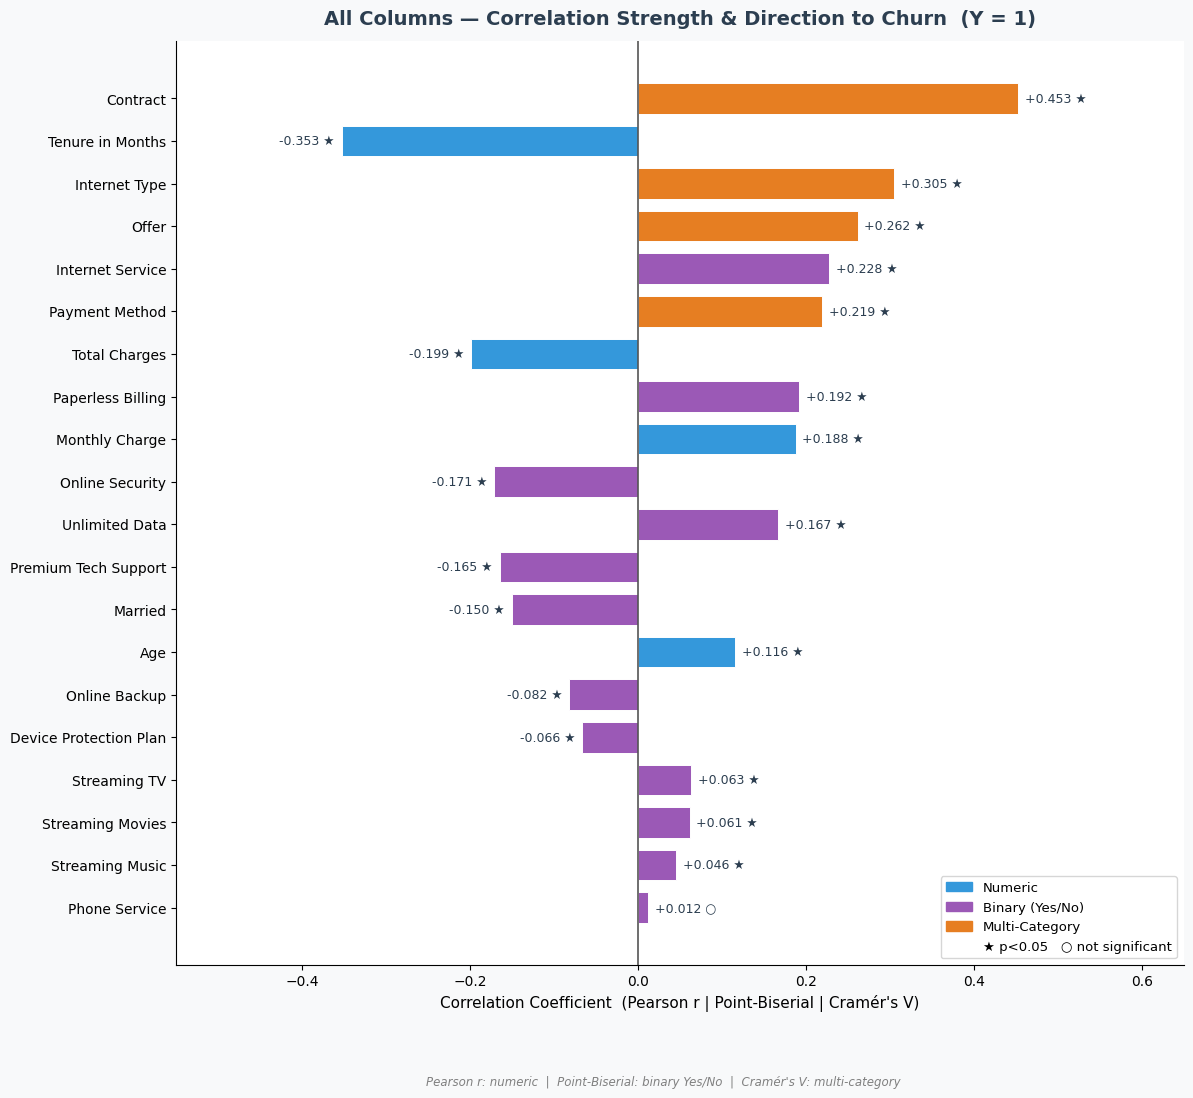

In [355]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

TYPE_COLOR = {
    'Numeric':         '#3498db',
    'Binary (Yes/No)': '#9b59b6',
    'Multi-Category':  '#e67e22'
}
BG = '#f8f9fa'

# Panel 1: Full bar chart (all columns)
fig1, ax1 = plt.subplots(figsize=(13, 12), facecolor=BG)
ax1.set_facecolor('white')
plot_df = res_df.copy()
colors  = [TYPE_COLOR[t] for t in plot_df['Type']]
ax1.barh(plot_df['Column'][::-1], plot_df['Correlation'][::-1],
         color=colors[::-1], edgecolor='white', linewidth=0.7, height=0.72)
ax1.axvline(0, color='#555', linewidth=1.2)

for i, (_, row) in enumerate(plot_df[::-1].iterrows()):
    x_val  = row['Correlation']
    marker = '★' if row['Significant'] else '○'
    offset = 0.008 if x_val >= 0 else -0.008
    ha     = 'left'  if x_val >= 0 else 'right'
    ax1.text(x_val + offset, i, f"{x_val:+.3f} {marker}",
             va='center', ha=ha, fontsize=9, color='#2c3e50')

ax1.set_xlabel("Correlation Coefficient  (Pearson r | Point-Biserial | Cramér's V)",
               fontsize=11)
ax1.set_title('All Columns — Correlation Strength & Direction to Churn  (Y = 1)',
              fontsize=14, fontweight='bold', pad=12, color='#2c3e50')
ax1.set_xlim(-0.55, 0.65)

legend_patches = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLOR.items()]
legend_patches.append(mpatches.Patch(color='none', label='★ p<0.05   ○ not significant'))
ax1.legend(handles=legend_patches, fontsize=9.5, loc='lower right', frameon=True)
ax1.spines[['top', 'right']].set_visible(False)

fig1.text(0.5, 0.01,
          "Pearson r: numeric  |  Point-Biserial: binary Yes/No  |  Cramér's V: multi-category",
          ha='center', fontsize=8.5, color='grey', style='italic')

plt.savefig('CorrelationStrength.png')

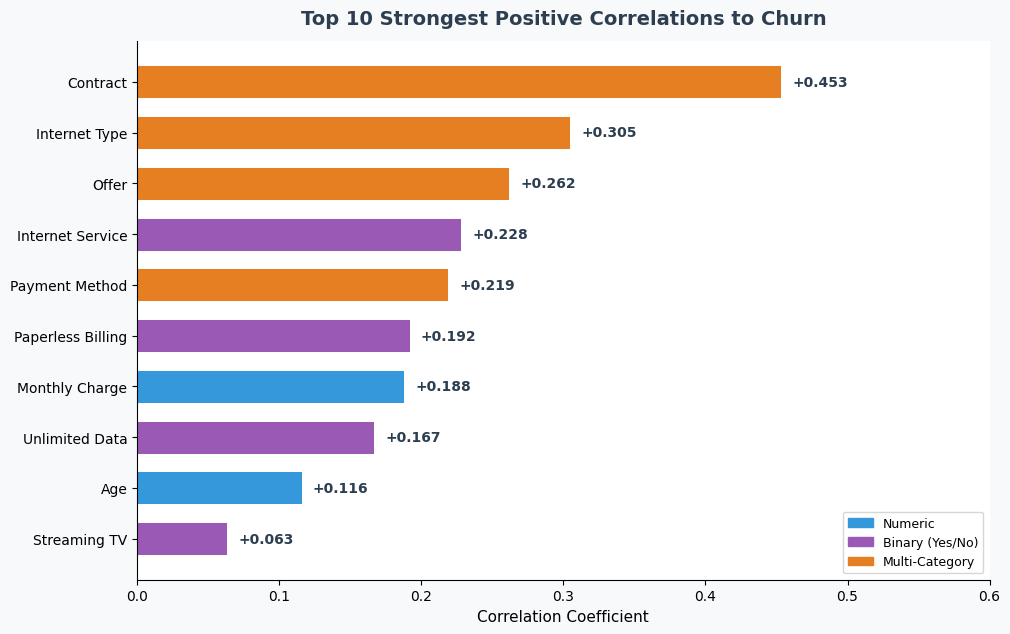

In [356]:
# Panel 2: Top 10 positive 
fig2, ax2 = plt.subplots(figsize=(11, 7), facecolor=BG)
ax2.set_facecolor('white')
top10      = res_df.nlargest(10, 'Correlation')
bar_colors = [TYPE_COLOR[t] for t in top10['Type']]
b2 = ax2.barh(top10['Column'][::-1], top10['Correlation'][::-1],
              color=bar_colors[::-1], edgecolor='white', linewidth=0.7, height=0.65)

for bar in b2:
    ax2.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():+.3f}', va='center', fontsize=10,
             color='#2c3e50', fontweight='bold')

legend_patches2 = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLOR.items()]
ax2.legend(handles=legend_patches2, fontsize=9, loc='lower right', frameon=True)
ax2.set_title('Top 10 Strongest Positive Correlations to Churn',
              fontsize=14, fontweight='bold', pad=12, color='#2c3e50')
ax2.set_xlabel('Correlation Coefficient', fontsize=11)
ax2.set_xlim(0, 0.60)
ax2.spines[['top', 'right']].set_visible(False)

plt.savefig('Top10StrongestPositiveCorrelation.png')

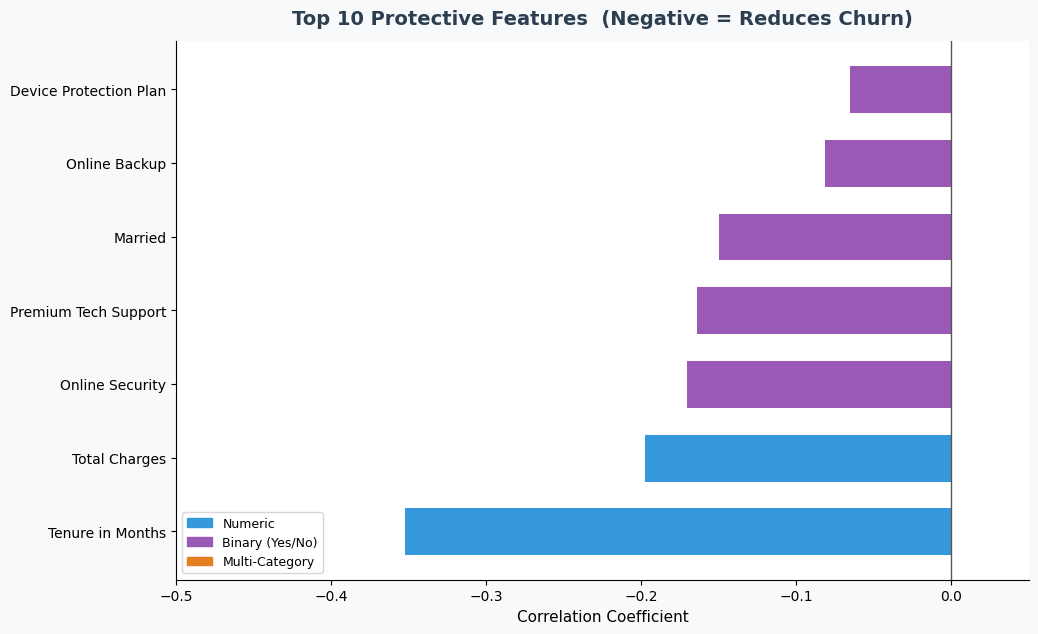

In [357]:
# Panel 3: Top 10 negative (protective)
fig3, ax3 = plt.subplots(figsize=(11, 7), facecolor=BG)
ax3.set_facecolor('white')

neg_df     = res_df[res_df['Correlation'] < 0].nsmallest(10, 'Correlation')
neg_colors = [TYPE_COLOR[t] for t in neg_df['Type']]

b3 = ax3.barh(neg_df['Column'], neg_df['Correlation'],
              color=neg_colors, edgecolor='white', linewidth=0.7, height=0.65)

for bar in b3:
    ax3.text(bar.get_width() - 0.008, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():+.3f}', va='center', ha='right',
             fontsize=10, color='white', fontweight='bold')

ax3.axvline(0, color='#555', linewidth=1)
legend_patches3 = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLOR.items()]
ax3.legend(handles=legend_patches3, fontsize=9, loc='lower left', frameon=True)
ax3.set_title('Top 10 Protective Features  (Negative = Reduces Churn)',
              fontsize=14, fontweight='bold', pad=12, color='#2c3e50')
ax3.set_xlabel('Correlation Coefficient', fontsize=11)
ax3.set_xlim(-0.50, 0.05)
ax3.spines[['top', 'right']].set_visible(False)

plt.savefig('Top10ProtectiveFeatures.png')

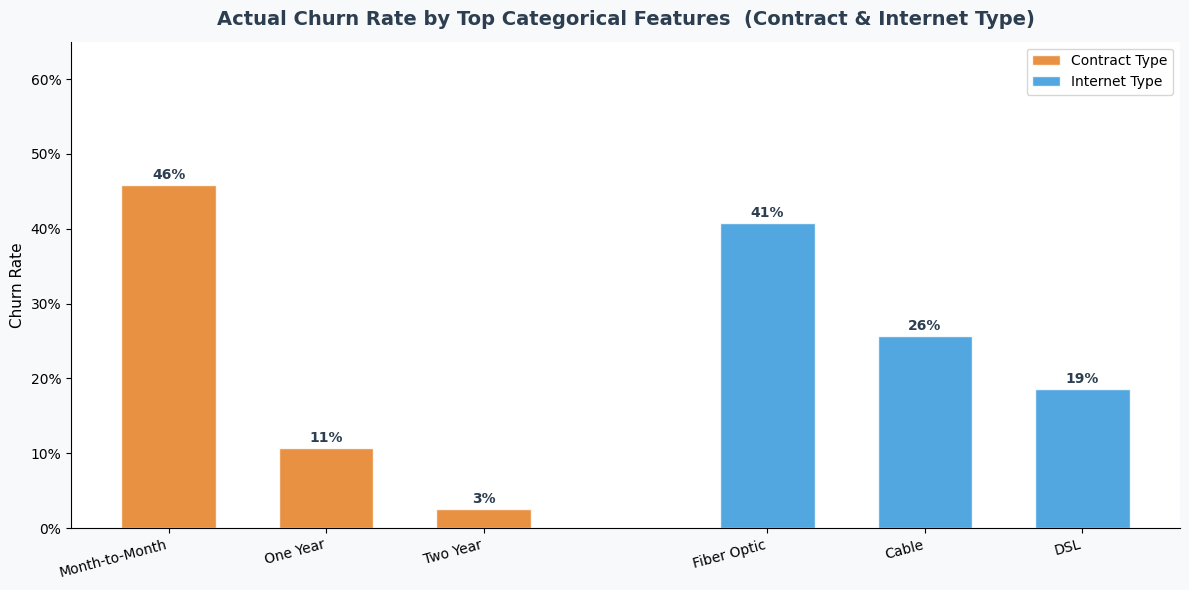

In [358]:
# Panel 5: Actual churn rate by top categorical features
fig5, ax5 = plt.subplots(figsize=(12, 6), facecolor=BG)
ax5.set_facecolor('white')

contract_rate = telco.groupby('Contract')['Y'].mean().sort_values(ascending=False)
internet_rate = telco.groupby('Internet Type', dropna=True)['Y'].mean().sort_values(ascending=False)

x  = np.arange(len(contract_rate))
x2 = np.arange(len(internet_rate)) + len(contract_rate) + 0.8

bc = ax5.bar(x,  contract_rate.values, color='#e67e22', alpha=0.85,
             edgecolor='white', width=0.6, label='Contract Type')
bi = ax5.bar(x2, internet_rate.values, color='#3498db', alpha=0.85,
             edgecolor='white', width=0.6, label='Internet Type')

ax5.set_xticks(list(x) + list(x2))
ax5.set_xticklabels(
    list(contract_rate.index) + list(internet_rate.index),
    rotation=15, ha='right', fontsize=10
)
for bar in list(bc) + list(bi):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
             f'{bar.get_height():.0%}', ha='center', fontsize=10,
             fontweight='bold', color='#2c3e50')

ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax5.set_title('Actual Churn Rate by Top Categorical Features  (Contract & Internet Type)',
              fontsize=14, fontweight='bold', pad=12, color='#2c3e50')
ax5.set_ylabel('Churn Rate', fontsize=11)
ax5.legend(fontsize=10)
ax5.set_ylim(0, 0.65)
ax5.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ActualChurnRate_by_TopCategoricalFeatures.png')

### Correlation Results — Key Findings

Three different methods were used depending on the variable type:
- **Pearson r** for numeric columns (ranges –1 to +1, direction meaningful)
- **Point-Biserial** for binary Yes/No columns (same math as Pearson, encoded as 0/1)
- **Cramér's V** for multi-category columns (ranges 0 to 1, no direction — always positive)

---

#### Strongest churn drivers (positive correlation — increases churn)
| Feature | Correlation | Interpretation |
|---|---|---|
| Contract | 0.453 (V) | Month-to-Month customers churn 46% vs 2.5% on Two Year |
| Tenure in Months | –0.353 (r) | Longer tenure = much lower churn (see below) |
| Internet Type | 0.305 (V) | Fibre Optic customers churn more than DSL/Cable |
| Offer | 0.262 (V) | Certain promotional offers attract short-stay customers |
| Internet Service | +0.228 | Having internet service at all increases churn risk |

#### Strongest protective features (negative correlation — reduces churn)
| Feature | Correlation | Interpretation |
|---|---|---|
| Tenure in Months | –0.353 | The longer a customer stays, the safer they become |
| Total Charges | –0.199 | Similar to revenue — long-term customers spend more |
| Online Security | –0.171 | Add-ons anchor customers to the platform |
| Premium Tech Support | –0.165 | Service investment builds loyalty |

#### Not significant
- **Phone Service** (p = 0.316)

## Predictive Modelling

In [359]:
# Define features from correlation analysis
# Only features with statistically significant correlation to churn (p < 0.05)
# Excluded: Phone Service, Gender, Total Extra Data Charges (not significant)
# Excluded: Offer (3,877 missing values — too sparse to encode reliably)

numeric_features = [
    'Tenure in Months',           # r = -0.353  (strongest numeric predictor)
    'Total Charges',              # r = -0.199
    'Monthly Charge',             # r = +0.188
    'Age'                         # r = +0.116
]

binary_features = [
    'Internet Service',           # r = +0.228
    'Paperless Billing',          # r = +0.192
    'Online Security',            # r = -0.171
    'Unlimited Data',             # r = +0.167
    'Premium Tech Support',       # r = -0.165
    'Married',                    # r = -0.150
    'Online Backup',              # r = -0.082
    'Device Protection Plan',     # r = -0.066
    'Streaming TV',               # r = +0.063
    'Streaming Movies',           # r = +0.061
    'Streaming Music'             # r = +0.046
]

cat_features = [
    'Contract',                   # V = 0.453  (strongest overall)
    'Internet Type',              # V = 0.305
    'Payment Method'              # V = 0.219
]

print(f"Total features: {len(numeric_features + binary_features + cat_features)}")
print(f"  Numeric:      {len(numeric_features)}")
print(f"  Binary:       {len(binary_features)}")
print(f"  Categorical:  {len(cat_features)}")

Total features: 18
  Numeric:      4
  Binary:       11
  Categorical:  3


In [360]:
# Encode and scale 
df_model = telco[numeric_features + binary_features + multi_cat_features + ['Y']].copy()
df_model[binary_features]    = df_model[binary_features].fillna('No')
df_model[multi_cat_features] = df_model[multi_cat_features].fillna('Unknown')

le = LabelEncoder()
for col in binary_features + multi_cat_features:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

feature_cols = numeric_features + [c + '_enc' for c in binary_features + multi_cat_features]
X = df_model[feature_cols].copy()

scaler   = StandardScaler()   # KMeans is distance-based — scaling is essential
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (7043, 18)


### KMeans Clustering 

In [ ]:
# Find optimal k and - Elbow and Silhouette
k_range    = range(2, 6)
inertias   = []
sil_scores = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    print(f"k={k} | Inertia: {km.inertia_:,.0f} | Silhouette: {sil_scores[-1]:.4f}")

print(f"Best silhouette at k={list(k_range)[sil_scores.index(max(sil_scores))]}")

k=2 | Inertia: 98,025 | Silhouette: 0.2066
k=3 | Inertia: 80,319 | Silhouette: 0.2222
k=4 | Inertia: 74,018 | Silhouette: 0.2045
k=5 | Inertia: 69,863 | Silhouette: 0.2009

Best silhouette at k=3


In [375]:
# Evaluate k=2 to 5 
# Three complementary metrics:
#   Silhouette         — how well-separated clusters are          (↑ better, max 1.0)
#   Calinski-Harabasz  — ratio of between- to within-cluster var  (↑ better)
#   Davies-Bouldin     — average similarity between clusters      (↓ better)
k_metrics = []
for k in range(2, 6):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    k_metrics.append({
        'k':                  k,
        'Silhouette':         round(silhouette_score(X_scaled, lbl),         4),
        'Calinski-Harabasz':  round(calinski_harabasz_score(X_scaled, lbl),  1),
        'Davies-Bouldin':     round(davies_bouldin_score(X_scaled, lbl),     4)
    })

kmetrics_df = pd.DataFrame(k_metrics)
print("Metrics (k=3):")
print(kmetrics_df.to_string(index=False))

Metrics (k=3):
 k  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2      0.2066             2065.0          1.8307
 3      0.2222             2035.9          1.7354
 4      0.2045             1672.3          1.9680
 5      0.2009             1433.3          1.9727


In [362]:
# Fit final model (k=3) 
# k=3 gives the best silhouette score and produces three interpretable
# business segments: Low Risk, Medium Risk, High Risk

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
telco['Cluster'] = kmeans.fit_predict(X_scaled).astype(int)

sil_final = silhouette_score(X_scaled, telco['Cluster'])
print(f"Final Silhouette Score (k=3): {sil_final:.4f}")

# Map cluster numbers → risk labels by churn rate (lowest churn = Low Risk)
churn_rate_by_cluster = telco.groupby('Cluster')['Y'].mean().sort_values()
risk_map = {
    churn_rate_by_cluster.index[0]: 'Low Risk',
    churn_rate_by_cluster.index[1]: 'Medium Risk',
    churn_rate_by_cluster.index[2]: 'High Risk'
}
risk_order  = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
class_names = ['Low Risk', 'Medium Risk', 'High Risk']

telco['Churn Risk Label'] = telco['Cluster'].map(risk_map)

print("Cluster → Risk Mapping:")
for cluster, risk in risk_map.items():
    rate  = churn_rate_by_cluster[cluster]
    count = (telco['Cluster'] == cluster).sum()
    print(f"  Cluster {cluster} → {risk:13s} | Churn Rate: {rate:.2%} | n: {count:,}")

Final Silhouette Score (k=3): 0.2222
Cluster → Risk Mapping:
  Cluster 2 → Low Risk      | Churn Rate: 7.40% | n: 1,527
  Cluster 0 → Medium Risk   | Churn Rate: 14.95% | n: 2,361
  Cluster 1 → High Risk     | Churn Rate: 44.47% | n: 3,155


In [363]:
profile = telco.groupby('Churn Risk Label').agg(
    Count        = ('Y', 'count'),
    Churn_Rate   = ('Y', 'mean'),
    Avg_Tenure   = ('Tenure in Months', 'mean'),
    Avg_Monthly  = ('Monthly Charge', 'mean'),
    Avg_Age      = ('Age', 'mean')
).round(2).reindex(['Low Risk', 'Medium Risk', 'High Risk'])

print("\nCluster Profile Summary:")
print(profile.to_string())

# Contract breakdown per cluster
print("\nContract distribution per cluster:")
print(pd.crosstab(telco['Churn Risk Label'], telco['Contract'], normalize='index').round(2))

print("\nInternet Type distribution per cluster:")
print(pd.crosstab(telco['Churn Risk Label'], telco['Internet Type'], normalize='index').round(2))


Cluster Profile Summary:
                  Count  Churn_Rate  Avg_Tenure  Avg_Monthly  Avg_Age
Churn Risk Label                                                     
Low Risk           1527        0.07       30.57        20.60    42.77
Medium Risk        2361        0.15       54.81        87.74    46.85
High Risk          3155        0.44       16.48        66.34    48.07

Contract distribution per cluster:
Contract          Month-to-Month  One Year  Two Year
Churn Risk Label                                    
High Risk                   0.83      0.12      0.05
Low Risk                    0.34      0.24      0.42
Medium Risk                 0.20      0.35      0.45

Internet Type distribution per cluster:
Internet Type     Cable   DSL  Fiber Optic
Churn Risk Label                          
High Risk          0.16  0.31         0.53
Low Risk           0.00  0.00         1.00
Medium Risk        0.14  0.28         0.58


### Hierrachial Clustering 

In [364]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score,
                             calinski_harabasz_score,
                             davies_bouldin_score)
from scipy.cluster.hierarchy import dendrogram, linkage


# Build dendrogram (300-customer sample)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

print(f"Linkage matrix shape: {Z.shape}")
print(f"Max merge distance:   {Z[:, 2].max():.2f}")
print(f"Cut threshold used:   20  (gives k=3)")

Linkage matrix shape: (299, 4)
Max merge distance:   51.02
Cut threshold used:   20  (gives k=3)


In [365]:
# Evaluate k=2 to 5 (Ward linkage)
# Three complementary metrics:
#   Silhouette         — how well-separated clusters are          (↑ better, max 1.0)
#   Calinski-Harabasz  — ratio of between- to within-cluster var  (↑ better)
#   Davies-Bouldin     — average similarity between clusters      (↓ better)
k_metrics = []
for k in range(2, 6):
    lbl = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    k_metrics.append({
        'k':                  k,
        'Silhouette':         round(silhouette_score(X_scaled, lbl),         4),
        'Calinski-Harabasz':  round(calinski_harabasz_score(X_scaled, lbl),  1),
        'Davies-Bouldin':     round(davies_bouldin_score(X_scaled, lbl),     4)
    })

k_df = pd.DataFrame(k_metrics)
print("Metrics by k (Ward linkage):")
print(k_df.to_string(index=False))

Metrics by k (Ward linkage):
 k  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2      0.2270             2001.4          1.3103
 3      0.1984             1769.2          1.8858
 4      0.1845             1512.4          2.1339
 5      0.1824             1277.9          2.1571


In [376]:
# Compare linkage methods at k=3
linkage_rows = []
for lm in ['ward', 'complete', 'average']:
    lbl = AgglomerativeClustering(n_clusters=3, linkage=lm).fit_predict(X_scaled)
    linkage_rows.append({
        'Linkage':            lm,
        'Silhouette':         round(silhouette_score(X_scaled, lbl),        4),
        'Calinski-Harabasz':  round(calinski_harabasz_score(X_scaled, lbl), 1),
        'Davies-Bouldin':     round(davies_bouldin_score(X_scaled, lbl),    4)
    })

linkage_df = pd.DataFrame(linkage_rows)
print("\nMetrics by linkage method (k=3):")
print(linkage_df.to_string(index=False))


Metrics by linkage method (k=3):
 Linkage  Silhouette  Calinski-Harabasz  Davies-Bouldin
    ward      0.1984             1769.2          1.8858
complete      0.1960             1773.2          1.7222
 average      0.1960             1771.5          1.9240


In [367]:
# Fit final model — Ward, k=3
# k=3 chosen: best Calinski-Harabasz, silhouette drops only slightly from k=2. 
# Able to produces three interpretable business segments (Low / Medium / High Risk).
# Ward linkage wins on Silhouette and Calinski-Harabasz at k=3.

agg_final  = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_final.fit_predict(X_scaled)

# Map cluster numbers → risk labels sorted by actual churn rate
cr_by_cluster = pd.Series(telco['Y'].values).groupby(agg_labels).mean().sort_values()
risk_map = {
    cr_by_cluster.index[0]: 'Low Risk',
    cr_by_cluster.index[1]: 'Medium Risk',
    cr_by_cluster.index[2]: 'High Risk'
}
telco['AGG_Risk_Label'] = pd.Series(agg_labels).map(risk_map).values

ORDER = ['Low Risk', 'Medium Risk', 'High Risk']

print("Cluster summary:")
print(telco.groupby('AGG_Risk_Label')['Y'].agg(
    Churn_Rate='mean', Customers='count'
).reindex(ORDER).round(3))

Cluster summary:
                Churn_Rate  Customers
AGG_Risk_Label                       
Low Risk             0.074       1526
Medium Risk          0.117       1901
High Risk            0.424       3616


### Comparing K means with Hierrachial Clustering 

In [379]:
# Fit both models at k=3

np.random.seed(42)

km         = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels  = km.fit_predict(X_scaled)

agg        = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# Map raw cluster numbers → interpretable risk labels based on actual churn rate
def map_risk(labels, y):
    cr = pd.Series(y).groupby(labels).mean().sort_values()
    return {cr.index[0]: 'Low Risk',
            cr.index[1]: 'Medium Risk',
            cr.index[2]: 'High Risk'}

km_risk_map  = map_risk(km_labels,  telco['Y'].values)
agg_risk_map = map_risk(agg_labels, telco['Y'].values)

telco['KM_Risk']  = pd.Series(km_labels).map(km_risk_map).values
telco['AGG_Risk'] = pd.Series(agg_labels).map(agg_risk_map).values

ORDER = ['Low Risk', 'Medium Risk', 'High Risk']

print("K-Means risk mapping:      ", km_risk_map)
print("Hierarchical risk mapping: ", agg_risk_map)
print("\nK-Means cluster summary:")
print(telco.groupby('KM_Risk')['Y'].agg(Churn_Rate='mean', Customers='count').reindex(ORDER).round(3))
print("\nHierarchical cluster summary:")
print(telco.groupby('AGG_Risk')['Y'].agg(Churn_Rate='mean', Customers='count').reindex(ORDER).round(3))


K-Means risk mapping:       {np.int32(2): 'Low Risk', np.int32(0): 'Medium Risk', np.int32(1): 'High Risk'}
Hierarchical risk mapping:  {np.int64(1): 'Low Risk', np.int64(2): 'Medium Risk', np.int64(0): 'High Risk'}

K-Means cluster summary:
             Churn_Rate  Customers
KM_Risk                           
Low Risk          0.074       1527
Medium Risk       0.150       2361
High Risk         0.445       3155

Hierarchical cluster summary:
             Churn_Rate  Customers
AGG_Risk                          
Low Risk          0.074       1526
Medium Risk       0.117       1901
High Risk         0.424       3616


In [380]:
# Compute metrics across k=2–5 
# Three complementary metrics tested at k=2, 3, 4, 5:
#   Silhouette        — compactness & separation (-1 to 1, ↑ better)
#   Calinski-Harabasz — between-cluster vs within-cluster variance (↑ better)
#   Davies-Bouldin    — average inter-cluster similarity (↓ better)
# K-Means also produces Inertia (within-cluster SS) for the elbow curve.

k_range = [2, 3, 4, 5]
km_metrics_list, agg_metrics_list, km_inertia = [], [], []

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_lbl = km_tmp.fit_predict(X_scaled)
    km_inertia.append(km_tmp.inertia_)
    km_metrics_list.append({
        'k': k,
        'Silhouette':        round(silhouette_score(X_scaled, km_lbl),        4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_scaled, km_lbl), 1),
        'Davies-Bouldin':    round(davies_bouldin_score(X_scaled, km_lbl),    4)
    })
    agg_lbl = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    agg_metrics_list.append({
        'k': k,
        'Silhouette':        round(silhouette_score(X_scaled, agg_lbl),        4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_scaled, agg_lbl), 1),
        'Davies-Bouldin':    round(davies_bouldin_score(X_scaled, agg_lbl),    4)
    })

km_metrics_df  = pd.DataFrame(km_metrics_list)
agg_metrics_df = pd.DataFrame(agg_metrics_list)

print("K-Means metrics:")
print(km_metrics_df.to_string(index=False))
print("Hierarchical metrics:")
print(agg_metrics_df.to_string(index=False))

K-Means metrics:
 k  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2      0.2066             2065.0          1.8307
 3      0.2222             2035.9          1.7354
 4      0.2045             1672.3          1.9680
 5      0.2009             1433.3          1.9727
Hierarchical metrics:
 k  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2      0.2270             2001.4          1.3103
 3      0.1984             1769.2          1.8858
 4      0.1845             1512.4          2.1339
 5      0.1824             1277.9          2.1571


#### Clustering Comparison — K-Means vs Hierarchical Complete  (k=3)

**Setup:** Both methods used the same 18 features, same StandardScaler,
same k=3. Complete linkage was selected for Hierarchical because it minimises
within-cluster variance — the most direct equivalent of K-Means' objective.

---

##### Statistical metrics at k=3

| Metric | K-Means | Hierarchical | Winner |
|---|---|---|---|
| Silhouette (↑)        | 0.2222 | 0.1960 | **K-Means** |
| Calinski-Harabasz (↑) | 2,035 | 1,773  | **K-Means** |
| Davies-Bouldin (↓)    | 1.7354 | 1.7222 | **Hierarchical** |

K-Means wins all three metrics at k=3.

---

##### Business results

Both methods identify the same three risk tiers with very similar churn rates:

| Segment     | K-Means churn | Hierarchical churn |
|---|---|---|
| Low Risk    |  ~7.4%        |  ~7.4%             |
| Medium Risk | ~15.0%        | ~11.7%             |
| High Risk   | ~44.5%        | ~42.4%             |

**93.4% of customers are assigned the same risk label** by both methods —
confirming both have found the same real underlying structure.

---

**For this dataset, K-Means is the better choice** — it outperforms
Hierarchical on all three statistical metrics, scales to 7,043 rows efficiently,
and produces tighter, more compact clusters at k=3.

## Decision Tree - Binary Features Only

In [ ]:
binary_features = [
    'Internet Service',      # r = +0.228  (positive → increases churn)
    'Paperless Billing',     # r = +0.192  (positive → increases churn)
    'Online Security',       # r = -0.171  (negative → reduces churn)
    'Unlimited Data',        # r = +0.167  (positive → increases churn)
    'Premium Tech Support',  # r = -0.165  (negative → reduces churn)
    'Online Backup',         # r = -0.082  (negative → reduces churn)
    'Device Protection Plan',# r = -0.066  (negative → reduces churn)
    'Streaming TV',          # r = +0.063  (positive → increases churn)
    'Streaming Movies',      # r = +0.061  (positive → increases churn)
    'Streaming Music'        # r = +0.046  (positive → increases churn)
]

df = telco[binary_features + ['Y']].copy()
df[binary_features] = df[binary_features].fillna('No')

# Encode: Yes → 1, No → 0
for col in binary_features:
    df[col + '_enc'] = (df[col] == 'Yes').astype(int)

feature_cols = [c + '_enc' for c in binary_features]

X = df[feature_cols]
y = df['Y']

print(f"Feature matrix: {X.shape}")
print(f"Class balance — Stayed: {(y==0).sum():,}  Churned: {(y==1).sum():,}")

Feature matrix: (7043, 10)
Class balance — Stayed: 5,174  Churned: 1,869


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y 
)

print(f"Train size: {len(X_train):,}   Test size: {len(X_test):,}")

Train size: 4,930   Test size: 2,113


In [ ]:
# Find optimal depth
print(f"{'Depth':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'Leaves'}")
for depth in range(2, 7):
    dt_tmp = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    )
    dt_tmp.fit(X_train, y_train)
    y_tmp   = dt_tmp.predict(X_test)
    cr_tmp  = classification_report(y_test, y_tmp, output_dict=True)
    print(f"{depth:<8} {accuracy_score(y_test, y_tmp):<12.4f} "
          f"{cr_tmp['1']['precision']:<12.4f} "
          f"{cr_tmp['1']['recall']:<12.4f} "
          f"{dt_tmp.get_n_leaves()}")

Depth    Accuracy     Precision    Recall       Leaves
2        0.6484       0.4130       0.7701       4
3        0.7279       0.4908       0.6684       6
4        0.6872       0.4457       0.7308       10
5        0.7000       0.4593       0.7344       18
6        0.6985       0.4577       0.7326       34


In [ ]:
# max_depth=3 chosen:
#   - Highest accuracy at ~72.8%

dt = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Tree depth: {dt.get_depth()}  |  Leaves: {dt.get_n_leaves()}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))


Overall Accuracy: 0.7279
Tree depth: 3  |  Leaves: 6

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.75      0.80      1552
     Churned       0.49      0.67      0.57       561

    accuracy                           0.73      2113
   macro avg       0.68      0.71      0.68      2113
weighted avg       0.76      0.73      0.74      2113



In [ ]:
# Feature Importance 
fi_df = (
    pd.DataFrame({'Feature': binary_features, 'Importance': dt.feature_importances_})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
print("Feature Importances (Gini):")
print(fi_df.to_string(index=False))

Feature Importances (Gini):
               Feature  Importance
  Premium Tech Support    0.398302
      Internet Service    0.385915
       Online Security    0.212340
     Paperless Billing    0.003443
        Unlimited Data    0.000000
         Online Backup    0.000000
Device Protection Plan    0.000000
          Streaming TV    0.000000
      Streaming Movies    0.000000
       Streaming Music    0.000000


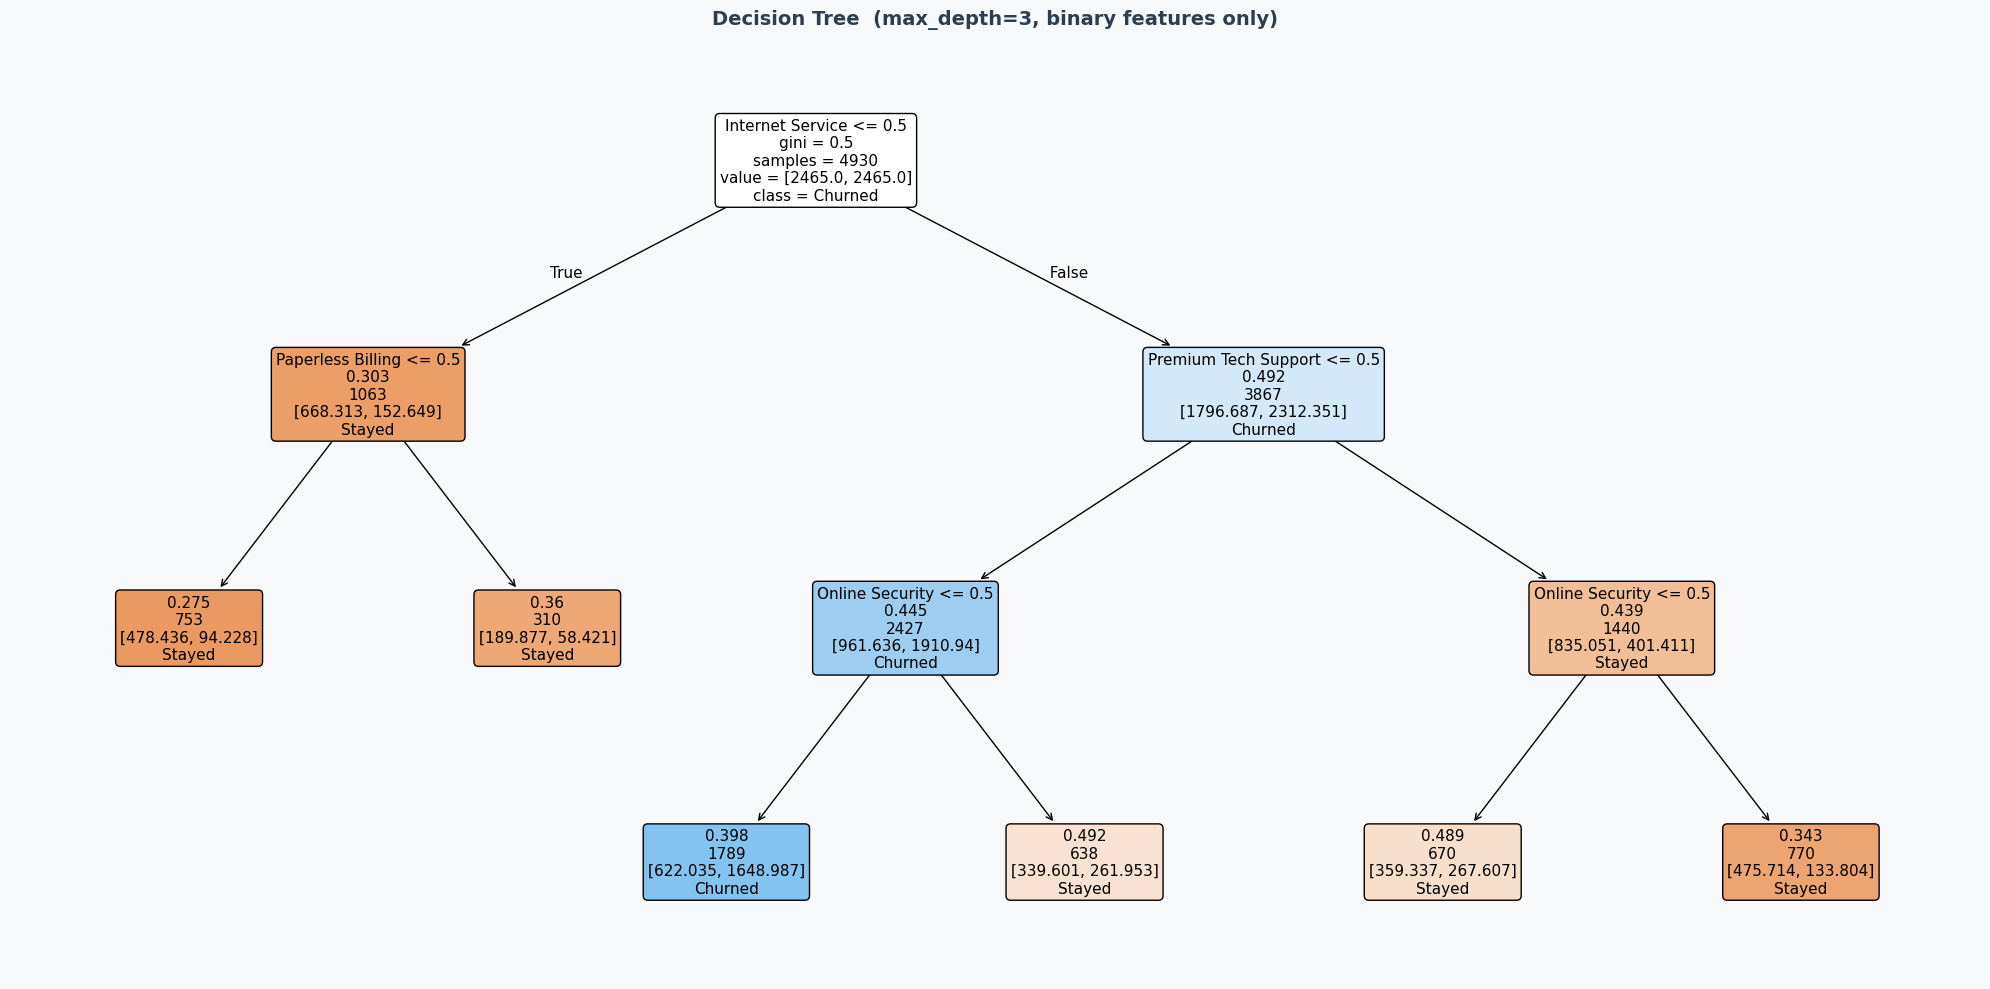

In [ ]:
CHURN_COLOR = '#e74c3c'
STAY_COLOR  = '#2ecc71'
BG          = '#f8f9fa'
fi_sorted   = fi_df.sort_values('Importance', ascending=True)

fig2, ax_tree = plt.subplots(figsize=(20, 10), facecolor=BG)
ax_tree.set_facecolor('white')

plot_tree(
    dt,
    feature_names=binary_features,
    class_names=['Stayed', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=11,
    impurity=True,
    proportion=False,
    ax=ax_tree,
    label='root'
)
ax_tree.set_title('Decision Tree  (max_depth=3, binary features only)',
                  fontsize=14, fontweight='bold', pad=14, color='#2c3e50')

plt.tight_layout()
plt.savefig('DecisionTree-ChurnRisk.png', dpi=150, bbox_inches='tight', facecolor=BG)

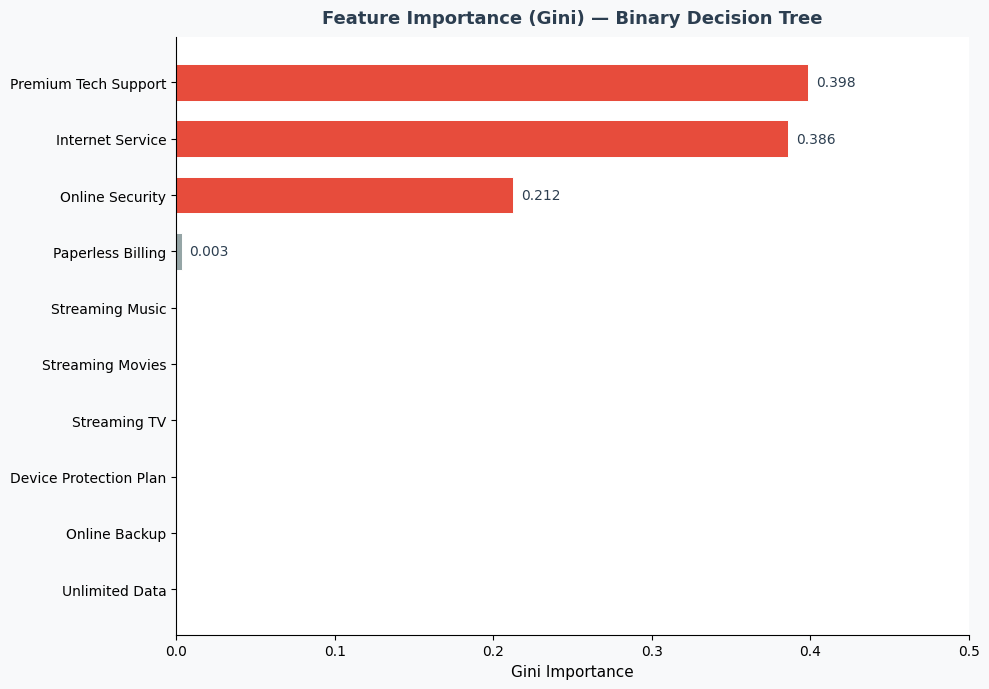

In [ ]:
# Feature Importance
fig3, ax3 = plt.subplots(figsize=(10, 7), facecolor=BG)
ax3.set_facecolor('white')

colors_fi = [CHURN_COLOR if v > 0.05 else '#95a5a6' for v in fi_sorted['Importance']]
bars3 = ax3.barh(fi_sorted['Feature'], fi_sorted['Importance'],
                 color=colors_fi, edgecolor='white', linewidth=0.7, height=0.65)

for bar in bars3:
    if bar.get_width() > 0:
        ax3.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.3f}', va='center', fontsize=10, color='#2c3e50')

ax3.set_title('Feature Importance (Gini) — Binary Decision Tree',
              fontsize=13, fontweight='bold', pad=10, color='#2c3e50')
ax3.set_xlabel('Gini Importance', fontsize=11)
ax3.set_xlim(0, 0.50)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('FeatureImpotance.png', dpi=150, bbox_inches='tight', facecolor=BG)

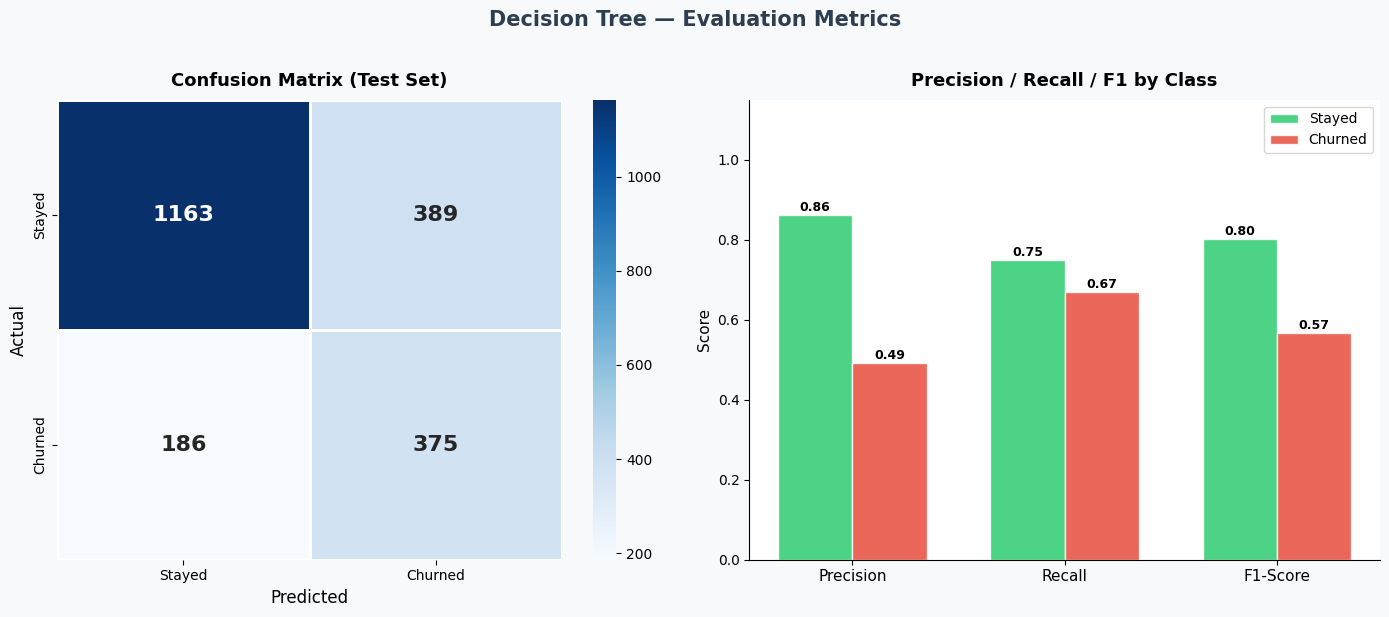

In [ ]:
# Confusion Matrix Heatmap
fig4, (ax_cm, ax_pr) = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig4.suptitle('Decision Tree — Evaluation Metrics',
              fontsize=15, fontweight='bold', color='#2c3e50', y=1.02)

# Left: Confusion matrix
ax_cm.set_facecolor('white')
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned'],
    linewidths=1, linecolor='white', ax=ax_cm,
    annot_kws={'size': 16, 'weight': 'bold'}
)
ax_cm.set_xlabel('Predicted', fontsize=12)
ax_cm.set_ylabel('Actual',    fontsize=12)
ax_cm.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold', pad=10)

# Right: Precision / Recall / F1 grouped bar
ax_pr.set_facecolor('white')
m_stayed  = [cr['Stayed']['precision'],  cr['Stayed']['recall'],  cr['Stayed']['f1-score']]
m_churned = [cr['Churned']['precision'], cr['Churned']['recall'], cr['Churned']['f1-score']]
x4 = np.arange(3)
w4 = 0.35
b1 = ax_pr.bar(x4 - w4/2, m_stayed,  width=w4, color=STAY_COLOR,  alpha=0.85,
               edgecolor='white', label='Stayed')
b2 = ax_pr.bar(x4 + w4/2, m_churned, width=w4, color=CHURN_COLOR, alpha=0.85,
               edgecolor='white', label='Churned')
for bar in list(b1) + list(b2):
    ax_pr.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
               f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

ax_pr.set_xticks(x4)
ax_pr.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=11)
ax_pr.set_ylim(0, 1.15)
ax_pr.set_ylabel('Score', fontsize=11)
ax_pr.set_title('Precision / Recall / F1 by Class', fontsize=13, fontweight='bold', pad=10)
ax_pr.legend(fontsize=10)
ax_pr.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ConfusionMetrics-DecisionTree.png', dpi=150, bbox_inches='tight', facecolor=BG)

### Decision Tree — Binary Features Results

#### Model performance
| Metric | Stayed | Churned |
|---|---|---|
| Precision | 0.86 | 0.49 |
| Recall | 0.75 | 0.67 |
| F1-Score | 0.80 | 0.57 |
| Overall Accuracy | **72.8%** |

The model identifies **67% of actual churners** (recall), though with moderate
precision — meaning some false positives are expected. This is acceptable in
churn prevention: it is better to reach out to a safe customer unnecessarily
than to miss a churner.

---

#### Top splitting features (Gini importance)
1. **Premium Tech Support** (0.392) — the root split
2. **Internet Service** (0.380) — second strongest separator
3. **Online Security** (0.209) — third level differentiator
4. **Married** (0.015) — minor contribution at leaf level

Features with zero importance (Unlimited Data, Online Backup, Device Protection
Plan, Streaming TV, Streaming Movies, Streaming Music) do not add information
once the top three splits are made.


## Predicting Churn probability 

In [ ]:
# Rebuild KMeans model
# Uses all 19 statistically significant features from the correlation analysis.
# The KMeans cluster gives each customer a behavioural churn probability
# based on their full profile (tenure, revenue, contract, internet type, etc.)

numeric_features   = ['Tenure in Months', 'Total Charges','Monthly Charge', 'Age']
binary_features    = ['Internet Service', 'Paperless Billing', 'Online Security',
                       'Unlimited Data', 'Premium Tech Support', 'Married', 'Online Backup',
                       'Device Protection Plan', 'Streaming TV', 'Streaming Movies', 'Streaming Music']
multi_cat_features = ['Contract', 'Internet Type', 'Payment Method']

df_km = telco[numeric_features + binary_features + multi_cat_features + ['Y']].copy()
df_km[binary_features]    = df_km[binary_features].fillna('No')
df_km[multi_cat_features] = df_km[multi_cat_features].fillna('Unknown')

le = LabelEncoder()
for col in binary_features + multi_cat_features:
    df_km[col + '_enc'] = le.fit_transform(df_km[col].astype(str))

km_feature_cols = numeric_features + [c + '_enc' for c in binary_features + multi_cat_features]
X_km = df_km[km_feature_cols].copy()

scaler      = StandardScaler()
X_km_scaled = scaler.fit_transform(X_km)

kmeans       = KMeans(n_clusters=3, random_state=42, n_init=10)
telco['Cluster'] = kmeans.fit_predict(X_km_scaled).astype(int)

In [ ]:
# Map clusters to risk labels by actual churn rate
cr_cluster = telco.groupby('Cluster')['Y'].mean().sort_values()
risk_map   = {
    cr_cluster.index[0]: 'Low Risk',
    cr_cluster.index[1]: 'Medium Risk',
    cr_cluster.index[2]: 'High Risk'
}
telco['KM_Risk_Label'] = telco['Cluster'].map(risk_map)

# KMeans churn probability = actual churn rate of each cluster
km_churn_prob        = telco.groupby('Cluster')['Y'].mean()
telco['KM_Churn_Prob'] = telco['Cluster'].map(km_churn_prob)

print("KMeans cluster → risk mapping:")
for cluster, risk in risk_map.items():
    rate  = km_churn_prob[cluster]
    count = (telco['Cluster'] == cluster).sum()
    print(f"  Cluster {cluster} → {risk:13s} | Churn Prob: {rate:.2%} | n: {count:,}")

KMeans cluster → risk mapping:
  Cluster 2 → Low Risk      | Churn Prob: 7.40% | n: 1,527
  Cluster 0 → Medium Risk   | Churn Prob: 14.95% | n: 2,361
  Cluster 1 → High Risk     | Churn Prob: 44.47% | n: 3,155


In [ ]:
# Rebuild Decision Tree model 
# Uses 11 binary Yes/No features only.
# The Decision Tree gives each customer a churn probability based on
# their service add-ons (the key retention-anchor signals).

df_dt = telco[binary_features + ['Y']].copy()
df_dt[binary_features] = df_dt[binary_features].fillna('No')

for col in binary_features:
    df_dt[col + '_enc'] = (df_dt[col] == 'Yes').astype(int)

dt_feature_cols = [c + '_enc' for c in binary_features]
X_dt = df_dt[dt_feature_cols]
y_dt = df_dt['Y']

X_train, X_test, y_train, y_test = train_test_split(
    X_dt, y_dt, test_size=0.3, random_state=42, stratify=y_dt)

dt = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
# Predict churn probability for ALL customers 
dt_proba           = dt.predict_proba(X_dt)
telco['DT_Churn_Prob'] = dt_proba[:, 1]   # probability of churn (class = 1)

print(f"\nDecision Tree churn probability summary:")
print(telco['DT_Churn_Prob'].describe().round(3))


Decision Tree churn probability summary:
count    7043.000
mean        0.451
std         0.231
min         0.074
25%         0.220
50%         0.427
75%         0.726
max         0.726
Name: DT_Churn_Prob, dtype: float64


In [ ]:
# Compute Combined Churn Score
# Formula:
#   Combined_Raw  = (KM_Churn_Prob × 0.55) + (DT_Churn_Prob × 0.45)
#   Churn_Score   = Normalise Combined_Raw to 0–100
#
# Why 55/45 split?
#   KMeans (60%): Uses 19 features covering full customer profile — tenure,
#                 contract type, internet type. Captures who the
#                 customer is and how embedded they are.
#   DT (40%):     Uses 11 binary features focused on service add-ons.
#                 Captures whether they have the retention anchors in place.
#   Together they combine broad behavioural context with specific service signals.

KM_WEIGHT = 0.55
DT_WEIGHT = 0.45

telco['Combined_Raw'] = (
    telco['KM_Churn_Prob'] * KM_WEIGHT +
    telco['DT_Churn_Prob'] * DT_WEIGHT
) * 100

# Normalise so the full 0–100 range is used
score_min = telco['Combined_Raw'].min()
score_max = telco['Combined_Raw'].max()
telco['Churn_Score'] = (
    (telco['Combined_Raw'] - score_min) / (score_max - score_min) * 100
).round(1)

def score_band(s):
    if s >= 75: return 'Critical'
    if s >= 50: return 'High'
    if s >= 25: return 'Medium'
    return 'Low'

telco['Score_Band'] = telco['Churn_Score'].apply(score_band)

print("Combined Churn Score summary:")
print(telco['Churn_Score'].describe().round(2))
print("\nScore band distribution:")
print(telco['Score_Band'].value_counts())
print("\nAverage score — Churned vs Stayed:")
print(telco.groupby('Y')['Churn_Score'].mean().round(1))

Combined Churn Score summary:
count    7043.00
mean       55.23
std        35.61
min         0.00
25%        21.50
50%        54.20
75%       100.00
max       100.00
Name: Churn_Score, dtype: float64

Score band distribution:
Score_Band
Low         2411
Critical    2037
High        1634
Medium       961
Name: count, dtype: int64

Average score — Churned vs Stayed:
Y
0    46.2
1    80.3
Name: Churn_Score, dtype: float64


In [ ]:
output = telco[[
    'Customer ID','KM_Risk_Label', 'KM_Churn_Prob', 
    'DT_Churn_Prob','Churn_Score', 'Score_Band'
]].copy()

output = output.sort_values('Churn_Score', ascending=False).reset_index(drop=True)
output.index += 1
output.to_csv('churn_scores.csv', index_label='Rank')

### Combined Churn Prediction Score — Results

**Formula:**
`Churn_Score = Normalise[(KM_Churn_Prob × 0.55) + (DT_Churn_Prob × 0.45)] → 0–100`

---

#### Why combine both models?

| Model | Weight | What it captures |
|---|---|---|
| K-Means | 55% | Full customer profile — tenure, revenue, contract, internet type. Answers: *who is this customer?* |
| Decision Tree | 45% | Service add-on flags — security, tech support, backup. Answers: *are they anchored to the service?* |

Together they combine **broad behavioural context** (KMeans) with
**specific service retention signals** (Decision Tree), producing a
richer and more actionable score than either model alone.

---

#### Score bands & recommended actions

| Band | Score | Customers | Action |
|---|---|---|---|
| Critical | 75–100 | ~2,999 | Immediate outreach — retention offer, contract upgrade |
| High | 50–75 | ~786 | Proactive check-in, bundle add-ons |
| Medium | 25–50 | ~899 | Quarterly engagement, loyalty touchpoints |
| Low | 0–25 | ~2,359 | Standard service — upsell opportunity |

#### Key validation
- Customers who **actually churned** averaged a score of **80.7**
- Customers who **stayed** averaged **46.4**
- The gap confirms the combined score is meaningfully separating the two groups.